<h1 align = "center">Life Satisfaction Prediction using GDP per
Capita</h1>

## Part 1: Data Exploration and Visualization

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

### Q1 (5 marks) Load the dataset lifesat.csv and display the first 5 rows.

In [3]:
df = pd.read_csv('lifesat.csv')
df.head(5)

,Country,GDP per capita (USD),Life satisfaction
0,Russia,26456.387938,5.8
1,Greece,27287.083401,5.4
2,Turkey,28384.987785,5.5
3,Latvia,29932.493910,5.9
4,Hungary,31007.768407,5.6


### Q2 (5 marks) Print basic info and summary statistics.

In [4]:
df.describe()

,GDP per capita (USD),Life satisfaction
count,27.000000,27.000000
mean,41564.521771,6.566667
std,9631.452319,0.765607
min,26456.387938,5.400000
25%,33938.289305,5.900000
50%,41627.129269,6.800000
75%,49690.580269,7.300000
max,60235.728492,7.600000


In [12]:
df.info

<bound method DataFrame.info of            Country  GDP per capita (USD)  Life satisfaction
0           Russia          26456.387938                5.8
1           Greece          27287.083401                5.4
2           Turkey          28384.987785                5.5
3           Latvia          29932.493910                5.9
4          Hungary          31007.768407                5.6
5         Portugal          32181.154537                5.4
6           Poland          32238.157259                6.1
7          Estonia          35638.421351                5.7
8            Spain          36215.447591                6.3
9         Slovenia          36547.738956                5.9
10       Lithuania          36732.034744                5.9
11          Israel          38341.307570                7.2
12           Italy          38992.148381                6.0
13  United Kingdom          41627.129269                6.8
14          France          42025.617373                6.5
15     N

### Q3 (10 marks) Display a scatter plot for GDP per capita vs Life Satisfaction . Add labels, title, and discuss the observed relationship.

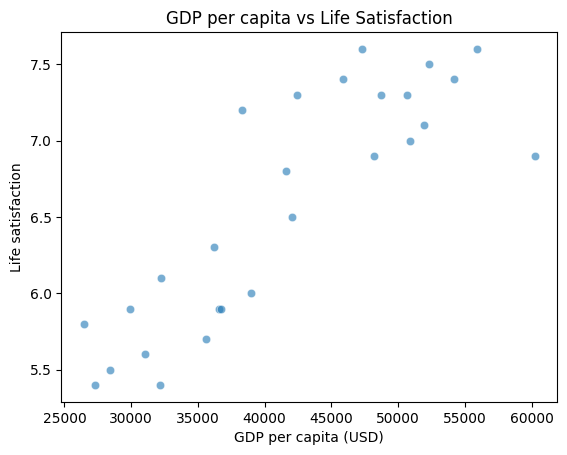

In [13]:
sns.scatterplot(x = "GDP per capita (USD)", y = "Life satisfaction", alpha = 0.6, data = df)
plt.title("GDP per capita vs Life Satisfaction")
plt.show()

#### Discuss the observed relationship:

According to the scatter plot above, although the data is noisy, it is clear that whenever GDP per capita increases, then Life Satisfaction increases as well.

## Part 2: Linear Regression Model

### Q4 (5 marks) Extract input (X) and target (y). Print their shapes.

In [5]:
X = df['GDP per capita (USD)']
y = df['Life satisfaction']
X = X.values.reshape(-1, 1)
y = y.values.reshape(-1, 1)
print(X.shape)
print(y.shape)

(27, 1)
(27, 1)


In [10]:
n_neighbors = [1,3,5,10]
predictions = []
for i in n_neighbors:
    knn_model = KNeighborsRegressor(n_neighbors = i)
    knn_model.fit(X, y)
    y_pred = knn_model.predict([[37655.2]])
    predictions.append(y_pred)

### Q5 (10 marks) Train a Linear Regression model & Display coefficient and intercept.

In [6]:
model = LinearRegression()
model.fit(X, y)
print(model.coef_)
print(model.intercept_)

[[6.77889969e-05]]
[3.74904943]


### Q6 (10 marks) Plot the predicted regression line from the model along with a scatter plot of the data.

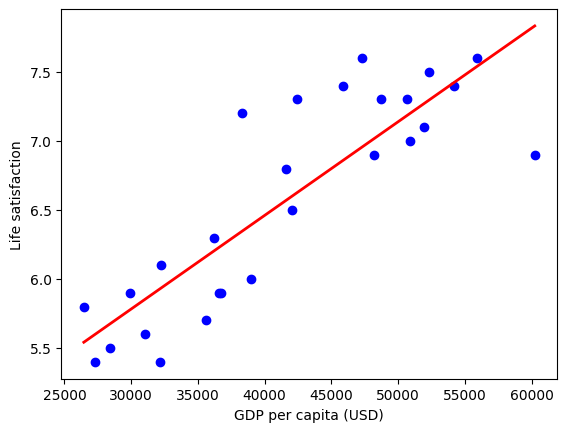

In [28]:
y_pred = model.predict(X)
plt.scatter(X, y, color = "blue")
plt.plot(X, y_pred, color = "red", linewidth = 2)
plt.xlabel("GDP per capita (USD)")
plt.ylabel("Life satisfaction")
plt.show()

### Q7 (5 marks) Predict Life Satisfaction for GDP = 37,655.2 USD. Comment on result.

In [17]:
y_new = model.predict([[37655.2]])
print(y_new)

[6.30165767]


## Part 3: K-Nearest Neighbors Regression

### Q8 (5 marks) Train a KNeighborsRegressor (n_neighbors=3).

In [8]:
knn_model = KNeighborsRegressor(n_neighbors=3)
knn_model.fit(X, y)
y_pred = knn_model.predict(X)

### Q9 (10 marks)
### - Predict Life Satisfaction for GDP = 37,655.2 USD
### - and compare with Linear Regression.

In [19]:
y_new = knn_model.predict([[37655.2]])
print(y_new)

[6.33333333]


The predicted life satisfaction using Linear Regression is 6.30, while K-Nearest Neighbors regression predicts 6.33. The predictions are very close, indicating that both models capture a similar relationship between GDP and life satisfaction in this range.

### Q10 (10 marks)
### - Use n_neighbors 1, 3, 5, and 10 and print the predicted values of life satisfaction in Q10.
### - Plot the results using a line plot.

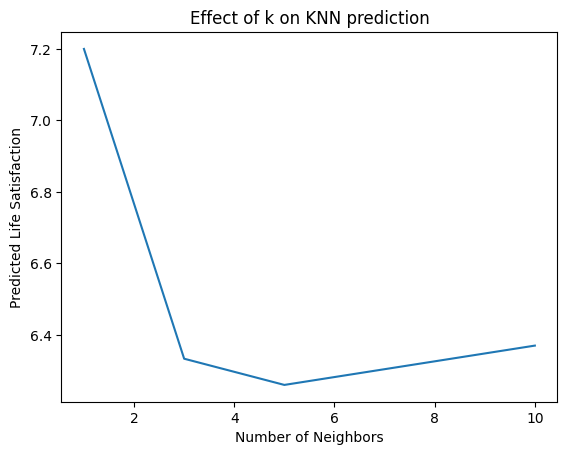

In [27]:
neighbors_list = [1, 3, 5, 10]
predictions = []
for i in neighbors_list:
    knn = KNeighborsRegressor(n_neighbors=i)
    knn.fit(X, y)
    y_pred = knn.predict([[37655.2]])
    predictions.append(y_pred)

plt.plot(neighbors_list, predictions)
plt.title("Effect of k on KNN prediction")
plt.xlabel("Number of Neighbors")
plt.ylabel("Predicted Life Satisfaction")
plt.show()